In [2]:
%config InlineBackend.figure_format = 'retina'
from common import *

default figsize: (3.3339558599695587, 2.0604980384530722)


In [11]:
df = read_trace("Qwen3-1.7B-32/1k.csv")
df.head(20)

,type,timestamp_us,chunk,count,layer,layer_idx,seq_len,token_idx
0,StartTracing,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,ModelLoadBegin,1049383,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,ModelLoadComplete,3193323,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,LoadParamBegin,3206074,-1,<NA>,0,<NA>,<NA>,<NA>
4,LoadParamComplete,3261972,-1,<NA>,0,<NA>,<NA>,<NA>
5,LoadParamBegin,3262056,-1,<NA>,1,<NA>,<NA>,<NA>
6,LoadParamComplete,3314423,-1,<NA>,1,<NA>,<NA>,<NA>
7,LoadParamBegin,3314474,-1,<NA>,2,<NA>,<NA>,<NA>
8,LoadParamComplete,3368499,-1,<NA>,2,<NA>,<NA>,<NA>
9,LoadParamBegin,3368566,-1,<NA>,3,<NA>,<NA>,<NA>


In [4]:
def parse_task_times(df, task_name):
    """Parse Begin/Complete event pairs and compute duration."""
    begin = df[df['type'] == f'{task_name}Begin'][['layer', 'chunk', 'timestamp_us']].rename(columns={'timestamp_us': 'begin_us'})
    complete = df[df['type'] == f'{task_name}Complete'][['layer', 'chunk', 'timestamp_us']].rename(columns={'timestamp_us': 'complete_us'})
    merged = pd.merge(begin, complete, on=['layer', 'chunk'])
    merged['duration_ms'] = (merged['complete_us'] - merged['begin_us']) / 1000
    merged['task'] = task_name
    return merged

task_names = ['LoadParam', 'LoadKV', 'LoadH', 'Compute']
tasks_df = pd.concat([parse_task_times(df, name) for name in task_names], ignore_index=True)

# Summary
tasks_df.groupby('task')['duration_ms'].agg(['count', 'mean', 'std', 'sum'])

,count,mean,std,sum
task,,,,
Compute,812,139.18057,12.972688,113014.623
LoadH,4,0.7975,0.335106,3.19
LoadKV,112,6.969714,3.80746,780.608
LoadParam,28,48.973536,4.032516,1371.259


In [5]:
# 计算参数加载总时间
loadparam_total = tasks_df[tasks_df['task'] == 'LoadParam']['duration_ms'].sum()
print(f"参数加载总时间: {loadparam_total} 毫秒")

参数加载总时间: 1371.259 毫秒


Text(0.5, 1.0, 'Time Breakdown by Task Type')

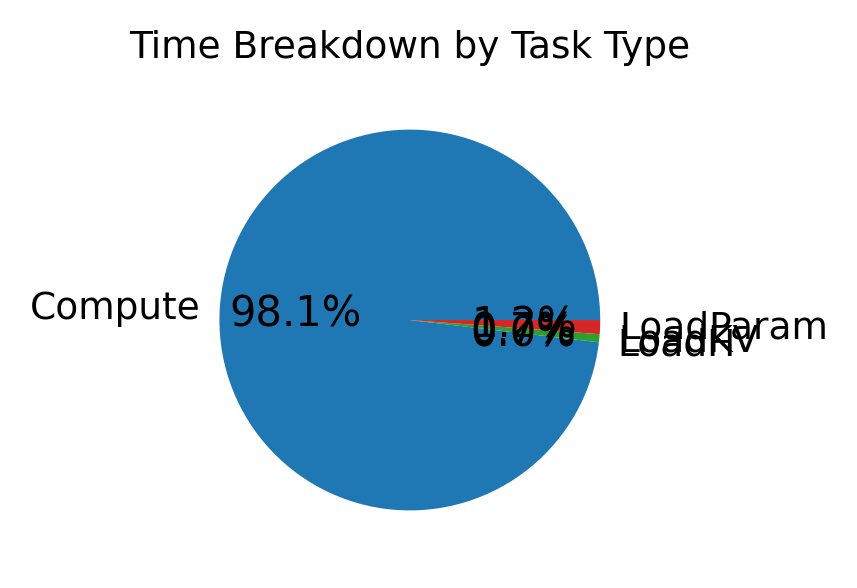

In [6]:
# Time breakdown pie chart
total_by_task = tasks_df.groupby('task')['duration_ms'].sum()
fig, ax = plt.subplots(figsize=figsize)
ax.pie(total_by_task, labels=total_by_task.index, autopct='%1.1f%%')
ax.set_title('Time Breakdown by Task Type')

Text(0.5, 0.98, '')

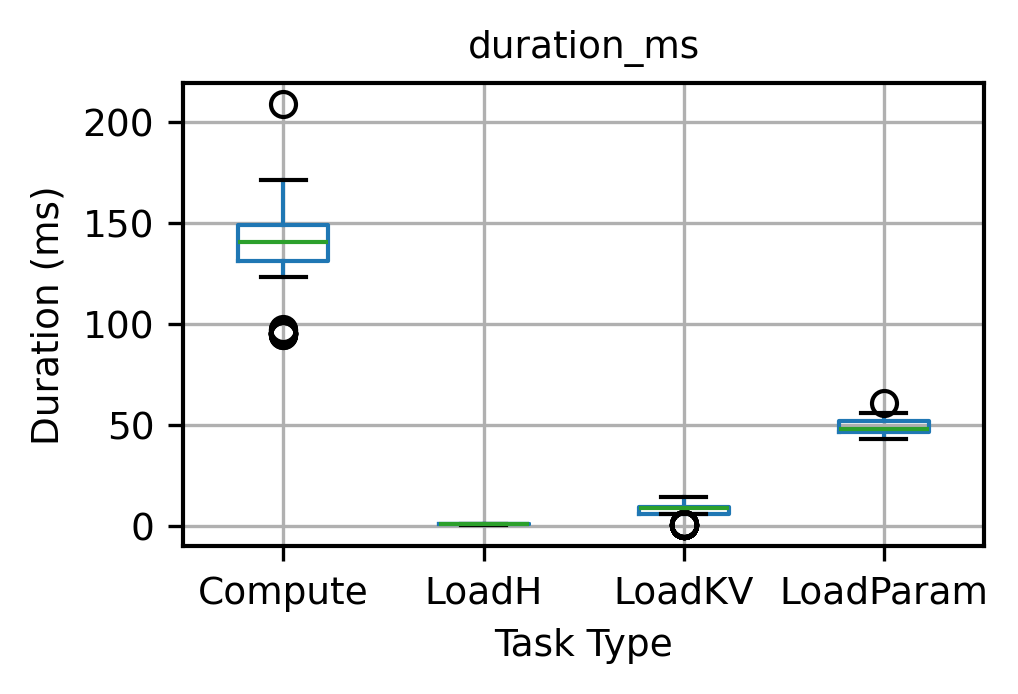

In [7]:
# Duration distribution
fig, ax = plt.subplots(figsize=figsize)
tasks_df.boxplot(column='duration_ms', by='task', ax=ax)
ax.set_xlabel('Task Type')
ax.set_ylabel('Duration (ms)')
plt.suptitle('')

Text(0, 0.5, 'Duration (ms)')

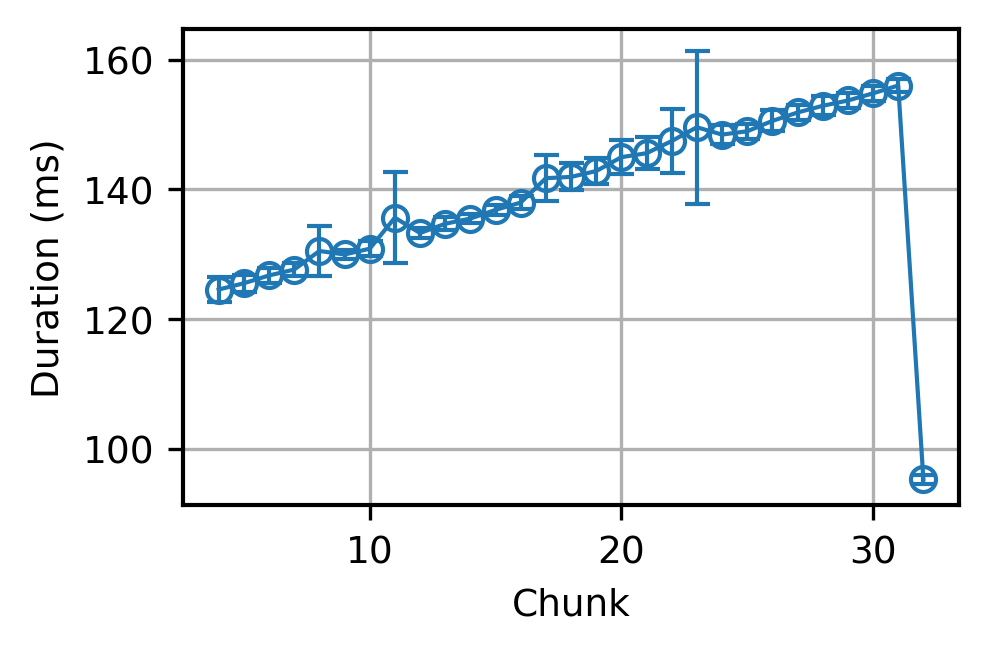

In [8]:
# Compute duration by layer
compute_df = tasks_df[tasks_df['task'] == 'Compute']
layer_stats = compute_df.groupby('chunk')['duration_ms'].agg(['mean', 'std'])

fig, ax = plt.subplots(figsize=figsize)
ax.errorbar(layer_stats.index, layer_stats['mean'], yerr=layer_stats['std'], marker='o', capsize=3)
ax.set_xlabel('Chunk')
ax.set_ylabel('Duration (ms)')

TypeError: Image data of dtype object cannot be converted to float

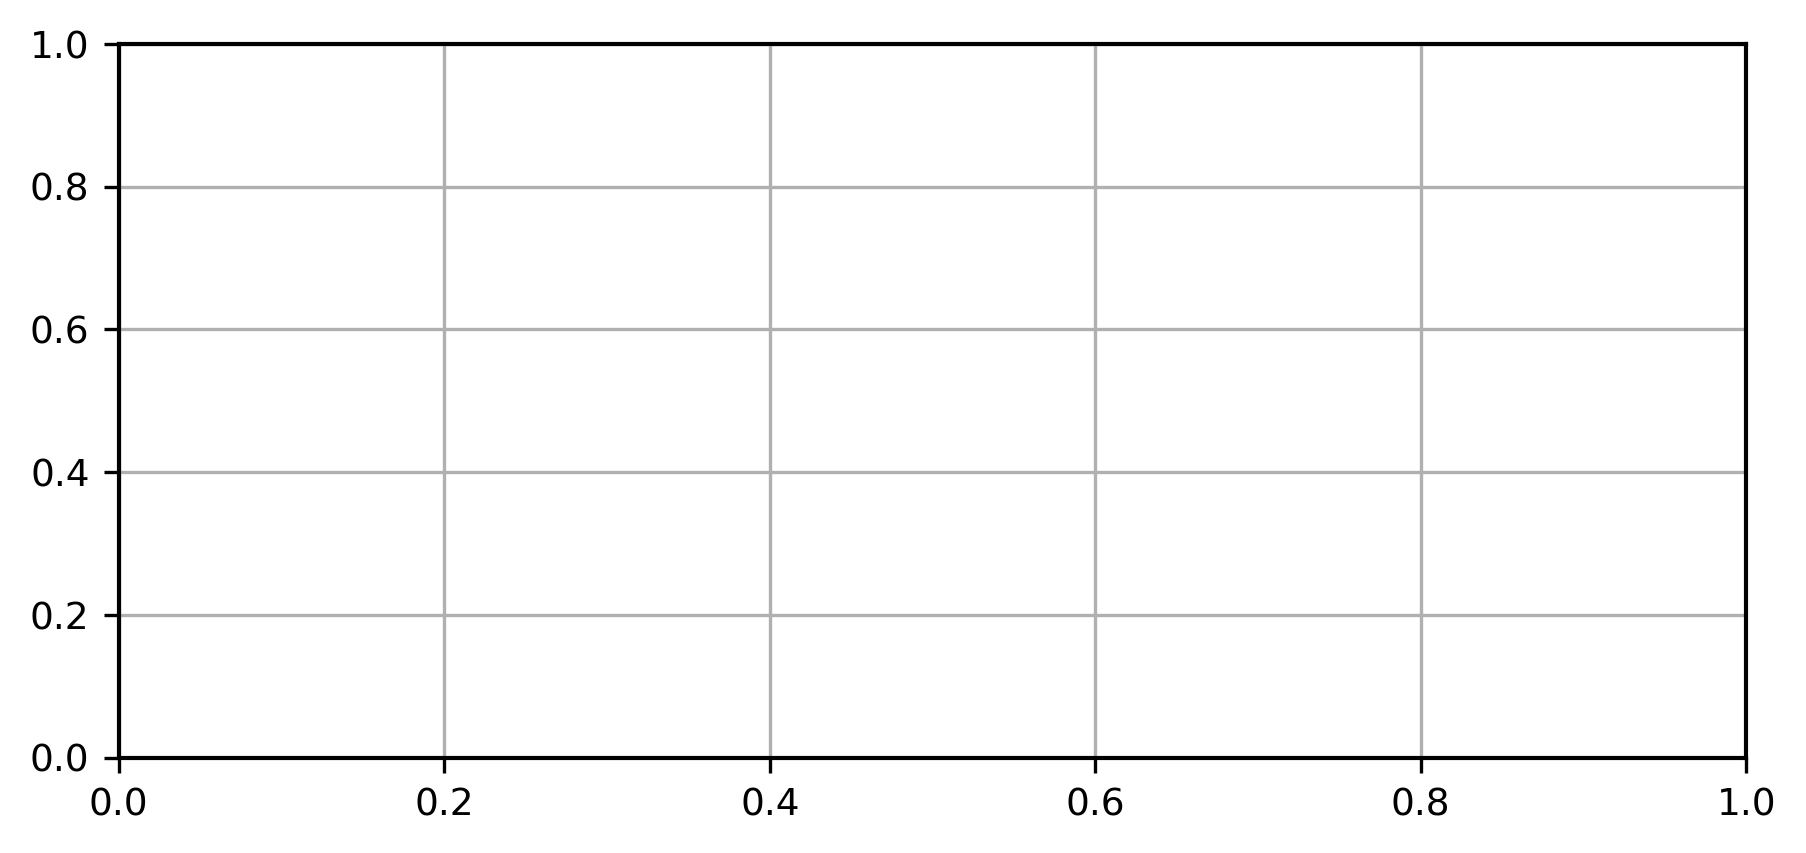

In [9]:
# Compute duration heatmap (layer x chunk)
pivot = compute_df.pivot_table(values='duration_ms', index='layer', columns='chunk')

fig, ax = plt.subplots(figsize=(full_width, default_height * 1.5))
im = ax.imshow(pivot, aspect='auto', cmap='YlOrRd')
ax.set_xlabel('Chunk')
ax.set_ylabel('Layer')
plt.colorbar(im, ax=ax, label='Duration (ms)')